# Paper Figure 4: STARR-seq and LUC Analysis Pipeline

This notebook documents the comprehensive workflow for analyzing STARR-seq data to generate **Figure 4**.
The pipeline consists of the following key steps:

1.  **Quality Control**: Filtering and trimming raw sequencing reads using Trimmomatic.
2.  **Read Alignment**: Mapping reads to reference promoter sequences using Bowtie2.
3.  **Plasmid Library Processing**: Establishing barcode-promoter correspondence and counting Input reads.
4.  **cDNA Library Processing**: Counting Output reads from cDNA sequencing.
5.  **Enrichment Calculation**: Computing promoter activity scores (Enrichment) based on Input/Output ratios.
6.  **Result Aggregation and Model Prediction**: Integrating replicates, mapping sequences, and predicting activity using TargetGAN.
7.  **Visualization of STARR-seq Results**: Generating the correlation plots and activity comparisons shown in Figure 4.
8.  **LUC Result Analysis**: Comparing STARR-seq measurements with LUC assay readouts for external experimental validation.

In [1]:
# Unified imports (used across all Python analysis cells below)
import os
# Specify CUDA device before importing tensorflow
os.environ["CUDA_VISIBLE_DEVICES"] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import tensorflow as tf

from utils import reversed_seq, get_median_row, one_hot_encode, suppress_tf_warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

# --- Set Font to Arial Globally ---
font_path = '/home/xlxiang/miniconda3/ARIAL.TTF'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
else:
    print(f"Font not found at {font_path}. Using default font.")

# Set general plotting parameters
plt.rcParams['font.size'] = 12
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.linewidth'] = 0.75

suppress_tf_warnings()

## 1. Quality Control
Use **Trimmomatic** to filter out low-quality reads and trim adapters from the raw sequencing data.


In [ ]:
!java -jar ./trimmomatic-0.39.jar PE -threads 50 ./SPO-P1R1-0120_raw_1.fq.gz ./SPO-P1R1-0120_raw_2.fq.gz ./SPO-P1R1-0120_1_trim_paired.fq.gz ./SPO-P1R1-0120_1_trim_unpaired.fq.gz ./SPO-P1R1-0120_2_trim_paired.fq.gz ./SPO-P1R1-0120_2_trim_unpaired.fq.gz ./TruSeq3-PE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:30

## 2. Read Alignment
Align the trimmed paired-end reads to the original reference sequences using **Bowtie2**.


### 2.1 Build Reference Index
Construct a Bowtie2 index for the known promoter sequences (`pro.fa`).


In [ ]:
!bowtie2-build ./data_for_plot/pro.fa ./data_for_plot/pro_index/pro

### 2.2 Align Reads
Perform the alignment to generate a SAM file containing the mapping results.


In [ ]:
!bowtie2 -p 20 --xeq --no-unal -x pro_index/pro -1 ./SPO-P1R2-0120_1_trim_paired.fq.gz -2 ./SPO-P1R2-0120_2_trim_paired.fq.gz -S pro.sam

### 2.3 Extract Alignment Information
Processes the SAM file to extract key information (Read ID, Gene, Position, CIGAR, Sequence) into a TSV format using `bioawk`.


In [ ]:
!cat pro.sam | bioawk -c sam -t 'BEGIN{print "read", "gene", "start", "cigar", "sequence"} {sub(/:[ACGTN+]*;.*$/, "", $qname); print $qname, $rname, $pos, $cigar, $seq}' > pro.tsv

## 3. Plasmid Library Processing
Run `plasmid_process.py` to:
1. Establish the correspondence between promoter sequences and barcodes.
2. Count the number of reads in the **Input** library.


In [ ]:
!python plasmid_process.py

## 4. cDNA Library Processing
Run `cdna_process.py` to:
1. Process the cDNA sequencing results.
2. Generate `cdna.text` containing the **Output** read counts.


In [ ]:
!python cdna_process.py

## 5. Calculate Enrichment Scores from STARR-seq Data
Perform enrichment analysis for 3 biological replicates. The process involves:
1.  **Data Loading**: Reading cDNA (Output) and Barcode-Promoter (Input) mapping files.
2.  **Filtering**: Removing barcodes that map to multiple promoters to ensure specificity.
3.  **Enrichment Calculation**: Computing sequences' activity using the log-ratio of Output/Input frequencies.
4.  **Normalization**: Adjusting scores relative to the internal control (35S promoter).
5.  **Aggregation**: Summarizing enrichment scores at the gene level.

In [29]:
# Define data path
result_path = '/dev_16T1/xlxiang/xxl_desktop/xlxiang/last_TargetGAN/figplot_code/STARR-seq/result/first-experimental'
result_df = {}

print("Starting Enrichment Calculation for 3 Replicates...")

for i in range(3):
    replicate_id = i + 1
    
    # ---------------------------------------------------------
    # 1. Process cDNA (Output) Library
    # ---------------------------------------------------------
    cdna_file = f'{result_path}/cdna_repeat{replicate_id}.txt'
    cdna = pd.read_csv(cdna_file)
    # Count frequency of each barcode in cDNA library
    counter = Counter(cdna['rever_bar'])
    df_cdna = pd.DataFrame(counter.items(), columns=['reversed_bar', 'output'])
    
    # ---------------------------------------------------------
    # 2. Process Plasmid (Input) Library
    # ---------------------------------------------------------
    bar_pro_file = f'{result_path}/bar_pro_repeat{replicate_id}.txt'
    bar_pro = pd.read_csv(bar_pro_file, index_col=0)
    # Generate reverse complement for barcodes to match cDNA sequencing direction
    bar_pro['reversed_bar'] = reversed_seq(list(bar_pro['bar']))
    
    # ---------------------------------------------------------
    # 3. Filter Promiscuous Barcodes
    # ---------------------------------------------------------
    # Identify barcodes mapping to a single promoter
    barcode_gene_counts = bar_pro.groupby('reversed_bar')['gene'].nunique().reset_index(name='num_pro')
    unique_mapping_barcodes = barcode_gene_counts[barcode_gene_counts['num_pro'] == 1]['reversed_bar']
    
    # Calculate and print specificity stats
    specificity_ratio = len(unique_mapping_barcodes) / bar_pro['reversed_bar'].nunique()
    print(f"Repeat {replicate_id}: {specificity_ratio:.2%} of barcodes map to a unique promoter.")
    
    # Keep only uniquely mapped barcodes
    valid_bar_pro = bar_pro[bar_pro['reversed_bar'].isin(unique_mapping_barcodes)]
    
    # Count frequency in Input library
    result_input = valid_bar_pro.groupby(['gene', 'reversed_bar']).size().reset_index(name='input')
    
    # ---------------------------------------------------------
    # 4. Calculate Enrichment
    # ---------------------------------------------------------
    # Merge Input and Output data
    result = result_input.merge(df_cdna, on='reversed_bar', how='inner')
    
    # Compute RPM (Reads Per Million) like normalization ratios
    total_input = result['input'].sum()
    total_output = result['output'].sum()
    
    # Enrichment = log2( (Output/Total_Output) / (Input/Total_Input) )
    result['enrichment'] = np.log2(
        (result['output'] / total_output) / 
        (result['input'] / total_input)
    )
    
    # Normalize to '35S' promoter baseline
    baseline_val = result.loc[result['gene'] == '35s', 'enrichment'].values[0]
    result['enrichment'] = result['enrichment'] - baseline_val
    
    # ---------------------------------------------------------
    # 5. Aggregate per Gene
    # ---------------------------------------------------------
    # For genes with multiple barcodes, select the median enrichment or specific row via utils
    result_with_median_row = result.groupby('gene', group_keys=False).apply(get_median_row)
    
    # Calculate final median enrichment per gene
    gene_enrichment = result.groupby('gene').apply(
        lambda x: x['enrichment'].median() if x['reversed_bar'].nunique() > 1 else x['enrichment'].iloc[0]
    ).reset_index(name='enrichment_median')
    
    result_df[i] = gene_enrichment
    print(f"---------------- Replicate {replicate_id} Processed ----------------")

print("All replicates processed successfully.")

Starting Enrichment Calculation for 3 Replicates...
Repeat 1: 89.53% of barcodes map to a unique promoter.
---------------- Replicate 1 Processed ----------------
Repeat 2: 89.52% of barcodes map to a unique promoter.
---------------- Replicate 2 Processed ----------------
Repeat 3: 85.21% of barcodes map to a unique promoter.
---------------- Replicate 3 Processed ----------------
All replicates processed successfully.


## 6. Result Aggregation and Model Prediction
Integrate results from all replicates to:
1.  **Merge Data**: Combine enrichment scores from the three replicates.
2.  **Statistical Analysis**: Calculate the average activity and Coefficient of Variation (CV).
3.  **Sequence Mapping**: Retrieve the corresponding DNA sequences for each gene.
4.  **Model Prediction**: Use the trained `TargetGAN` predictor to estimate activity.
5.  **Quality Filtering**: Exclude data points with high variability (CV > 30%).

In [30]:
# ---------------------------------------------------------
# 1. Merge Replicates
# ---------------------------------------------------------
# Merge the three result dataframes on 'gene'
last_df = result_df[0].merge(result_df[1], on='gene').merge(result_df[2], on='gene')

# Rename columns for clarity
col_mapping = {
    'enrichment_median_x': 'log2(experimental activity, repetition 1)',
    'enrichment_median_y': 'log2(experimental activity, repetition 2)',
    'enrichment_median': 'log2(experimental activity, repetition 3)'
}
last_df = last_df.rename(columns=col_mapping)

# ---------------------------------------------------------
# 2. Calculate Statistics
# ---------------------------------------------------------
activity_cols = list(col_mapping.values())

# Calculate Average (on log2 scale)
last_df['log2(activity_avg)'] = last_df[activity_cols].mean(axis=1)
last_df['CV (%)'] = np.abs(last_df[activity_cols].std(axis=1) / last_df[activity_cols].mean(axis=1)) * 100

# Remove the first row if it contains artifacts/headers (based on previous logic)
last_df = last_df.iloc[1:, :]

# ---------------------------------------------------------
# 3. Map Sequences
# ---------------------------------------------------------
mapping_file = './data_for_plot/sequence_to_name_mapping.xlsx'
seq_mapping = pd.read_excel(mapping_file)

# Merge with sequence mapping
last_df = last_df.merge(seq_mapping, left_on='gene', right_on='name2')

# Clean up columns: convert name2/sequence duplicates
if 'sequence_x' in last_df.columns and 'sequence_y' in last_df.columns:
    last_df['sequence'] = last_df['sequence_x']
    last_df = last_df.drop(columns=['sequence_x', 'sequence_y'])

cols_to_drop = [c for c in ['name2', 'name2_x', 'name2_y'] if c in last_df.columns]
last_df = last_df.drop(columns=cols_to_drop, errors='ignore')

# ---------------------------------------------------------
# 4. Predict Activity with TargetGAN
# ---------------------------------------------------------
model_path = '../data/predictor.h5'
print(f"Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path)

# One-hot encode sequences for prediction
input_seqs = np.array([one_hot_encode(seq) for seq in last_df['sequence'].tolist()])
print(f"Predicting activity for {len(input_seqs)} sequences...")
predictions = model.predict(input_seqs, batch_size=512, verbose=0)

last_df['log2(predicted_activity)'] = predictions

# ---------------------------------------------------------
# 5. Filter & Save
# ---------------------------------------------------------
# Filter out high variance data points (CV > 30%)
initial_count = len(last_df)
last_df = last_df[last_df['CV (%)'] <= 30]
filtered_count = len(last_df)
print(f"Filtered {initial_count - filtered_count} sequences with CV > 30%. Remaining: {filtered_count}")

# Save to Excel
output_file = './data_for_plot/starr_seq_result.xlsx'
last_df.set_index('name1', inplace=True)
last_df.to_excel(output_file, index=True)
print(f"Results saved to {output_file}")

# Display first few rows
last_df.head()

Loading model from ../data/predictor.h5...


2026-02-25 13:04:47.698868: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2026-02-25 13:04:47.742002: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:d5:00.0 name: NVIDIA GeForce RTX 3090 computeCapability: 8.6
coreClock: 1.695GHz coreCount: 82 deviceMemorySize: 23.69GiB deviceMemoryBandwidth: 871.81GiB/s
2026-02-25 13:04:47.742066: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2026-02-25 13:04:47.760146: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2026-02-25 13:04:47.760342: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11
2026-02-25 13:04:47.773330: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcu

Predicting activity for 4510 sequences...


2026-02-25 13:04:50.671836: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2026-02-25 13:04:50.690650: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2100000000 Hz
2026-02-25 13:04:52.022820: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2026-02-25 13:04:52.731677: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8201
2026-02-25 13:04:53.872967: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2026-02-25 13:04:54.490554: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


Filtered 930 sequences with CV > 30%. Remaining: 3580
Results saved to ./data_for_plot/starr_seq_result.xlsx


,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
NP750,Actin,2.522596,2.094205,2.254300,2.290367,9.450932,CCAGTCCCCACGGCCGTCACGCTCGCAGCACCGGCCGTTTTCTACG...,-1.255382
NP93,ENSRNA049469069,2.393902,3.611702,3.143104,3.049570,20.142665,CTAGCTCCAGCTTCCAGCCATGCCTCACCCCTCATGGCATGGCTGG...,-0.398657
NP666,ENSRNA049481266,2.393902,2.261205,2.277020,2.310709,3.136691,ACACACCCCTCTATAAACCCCTCATGCCATCTGCCTTCTTCATTCA...,-1.171234
NP555,ENSRNA049481968,2.300793,1.939277,2.416245,2.218772,11.215111,GGCCCCCCTGTCATCCGCTGCTACGCCAATGCAATGTCCTACAGTA...,-1.188979
NP471,ENSRNA049483182,1.602828,2.524240,2.970507,2.365858,29.480191,AAGAACCACGTACAATGCTCACAGGGGCGGCGTCAGCTAGCTAGCT...,-1.585087


## 7. Visualization of Results

In [31]:
SPs_df = last_df[last_df.index.str.startswith('SP')]
SPs_df.head()

,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
SP1008,PP-1008F,4.300793,4.797258,5.460668,4.852906,11.991507,CCACACCCCGGGGTCTATAAAACCCGCCACGCGAACCCACCCTCCA...,3.992136
SP100,PP-100F,4.393902,3.846168,3.031908,3.757326,18.239825,CTACCCCCTCCTGATCGATCCTCGCCTATAAATACCCCTCGCCCCC...,5.142095
SP1018,PP-1018F,2.201257,3.398709,3.090801,2.896922,21.464969,GGCACCCTTGGATAGAGGGCACGCCCTATATATATCCCCCCCCCCA...,3.989184
SP1020,PP-1020F,3.853334,3.024240,3.906377,3.594650,13.762158,GCGTGAACATGTCCAGATAGCCAATCCCATCCAGCCAGATCTCCAG...,3.987436
SP1021,PP-1021F,3.393902,3.524240,3.254300,3.390814,3.981232,AGATGCAAACTAGGGGCAAAAAAGTGCGTATCCAGGGCCCGTGCCT...,3.986558


In [32]:
NPs_df = last_df[last_df.index.str.startswith('NP')]
NPs_df.head()

,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
NP750,Actin,2.522596,2.094205,2.254300,2.290367,9.450932,CCAGTCCCCACGGCCGTCACGCTCGCAGCACCGGCCGTTTTCTACG...,-1.255382
NP93,ENSRNA049469069,2.393902,3.611702,3.143104,3.049570,20.142665,CTAGCTCCAGCTTCCAGCCATGCCTCACCCCTCATGGCATGGCTGG...,-0.398657
NP666,ENSRNA049481266,2.393902,2.261205,2.277020,2.310709,3.136691,ACACACCCCTCTATAAACCCCTCATGCCATCTGCCTTCTTCATTCA...,-1.171234
NP555,ENSRNA049481968,2.300793,1.939277,2.416245,2.218772,11.215111,GGCCCCCCTGTCATCCGCTGCTACGCCAATGCAATGTCCTACAGTA...,-1.188979
NP471,ENSRNA049483182,1.602828,2.524240,2.970507,2.365858,29.480191,AAGAACCACGTACAATGCTCACAGGGGCGGCGTCAGCTAGCTAGCT...,-1.585087


### 7.1 Correlation between Three Replicates

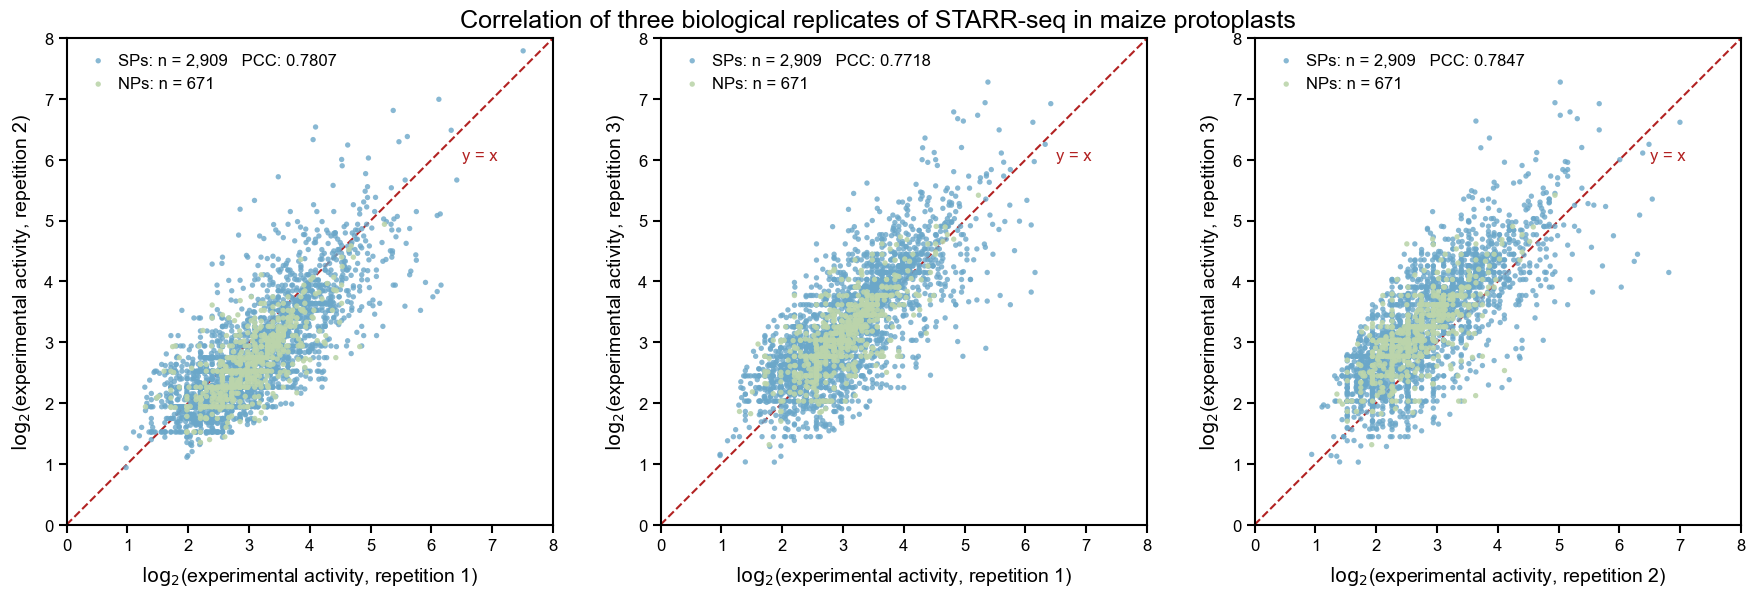

In [35]:
# 1. Calculate stats (counts are constant across plots as per example)
n_sps = SPs_df.shape[0]
n_nps = NPs_df.shape[0]

# Set up the figure size and subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the columns for the three replicates
col_rep1 = 'log2(experimental activity, repetition 1)'
col_rep2 = 'log2(experimental activity, repetition 2)'
col_rep3 = 'log2(experimental activity, repetition 3)'

# Define the pairs to plot: (x_column, y_column)
pairs = [
    (col_rep1, col_rep2),
    (col_rep1, col_rep3),
    (col_rep2, col_rep3)
]

lims = [0, 8]

# Helper function to plot each scatter
for ax, (x_col, y_col) in zip(axes, pairs):
    pcc_sp, _ = pearsonr(SPs_df[x_col], SPs_df[y_col])
    
    # Plot y=x diagonal line (zorder=1, bottom)
    ax.plot(lims, lims, color='firebrick', linestyle='--', linewidth=1.5, zorder=1)
    ax.text(6.5, 6, 'y = x', fontsize=12, fontweight='bold', color='firebrick')
    
    # Plot SPs (zorder=2, middle)
    ax.scatter(SPs_df[x_col], SPs_df[y_col], 
               s=15, c='#6ba7c9', 
               label=f'SPs: n = {n_sps:,}   PCC: {pcc_sp:.4f}', 
               zorder=2, edgecolors='none', alpha=0.8)
    
    # Plot NPs (zorder=3, top)
    ax.scatter(NPs_df[x_col], NPs_df[y_col], 
               s=15, c='#bcd5ab', 
               label=f'NPs: n = {n_nps:,}', 
               zorder=3, edgecolors='none', alpha=0.9)
    
    # Map column names to LaTeX format for labels
    xlabel = x_col.replace('log2', r'$\log_2$')
    ylabel = y_col.replace('log2', r'$\log_2$')
    
    # Set axis limits and labels
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=8)
    
    # Force square aspect ratio
    ax.set_aspect('equal', adjustable='box')

    # Set spines linewidth
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')
    
    ax.tick_params(axis='both', which='major', width=1.5, length=6, direction='out', labelsize=12)
    
    # Add legend - Removing frame as requested
    leg = ax.legend(loc='upper left', frameon=False, fontsize=12, 
                    handletextpad=0.2, borderaxespad=0.5)

# Set the overall title
fig.suptitle('Correlation of three biological replicates of STARR-seq in maize protoplasts', fontsize=18, fontweight='bold', y=0.95)

plt.tight_layout()
# plt.savefig('./data_for_plot/figure4_replicate_correlation.svg', dpi=600)
plt.show()

### 7.2 Correlation between Predicted and Experimental Activity of SPs

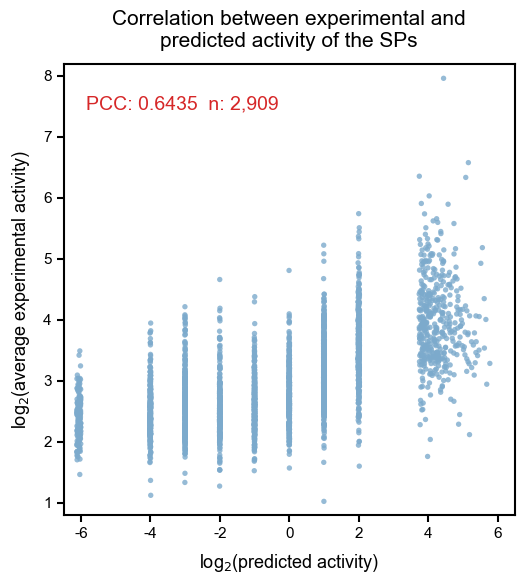

In [39]:
# Prepare data
x_col = 'log2(predicted_activity)'
y_col = 'log2(activity_avg)'
clean_data = SPs_df[[x_col, y_col]].dropna()
x = clean_data[x_col]
y = clean_data[y_col]

# Calculate Statistics
pcc, _ = pearsonr(x, y)
n_count = len(clean_data)

# Setup Figure
fig, ax = plt.subplots(figsize=(6, 6)) # Square figure

# Scatter Plot
# Using a color similar to the reference image
ax.scatter(x, y, color='#7CAACC', s=15, alpha=0.8, edgecolors='none', zorder=5)

# Add Annotation Text (Red, Top Left)
stats_text = f'PCC: {pcc:.4f}  n: {n_count:,}'
ax.text(0.05, 0.93, stats_text, transform=ax.transAxes, 
        fontsize=14, fontweight='bold', color='#D62728', verticalalignment='top')

# Labels and Title
ax.set_xlabel(r'log$_2$(predicted activity)', fontsize=13, labelpad=8)
ax.set_ylabel(r'log$_2$(average experimental activity)', fontsize=13, labelpad=8)
ax.set_title('Correlation between experimental and\npredicted activity of the SPs', fontsize=15, fontweight='bold', pad=12)

# Set Axis Limits
# The reference image has x ticks from -6 to 6, y from 1 to 8
ax.set_xlim(-6.5, 6.5)
ax.set_ylim(0.8, 8.2)

# Force the plot area to be square
ax.set_box_aspect(1)

# Customize Spines (Thicker borders)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=11, width=1.5, length=5, direction='out')

plt.tight_layout()
# plt.savefig('./data_for_plot/figure4_predicted_vs_exp.svg', dpi=600)
plt.show()

### 7.3 Comparison of Natural Promoter Activities Measured in This Study and Those Reported by Jores et al.

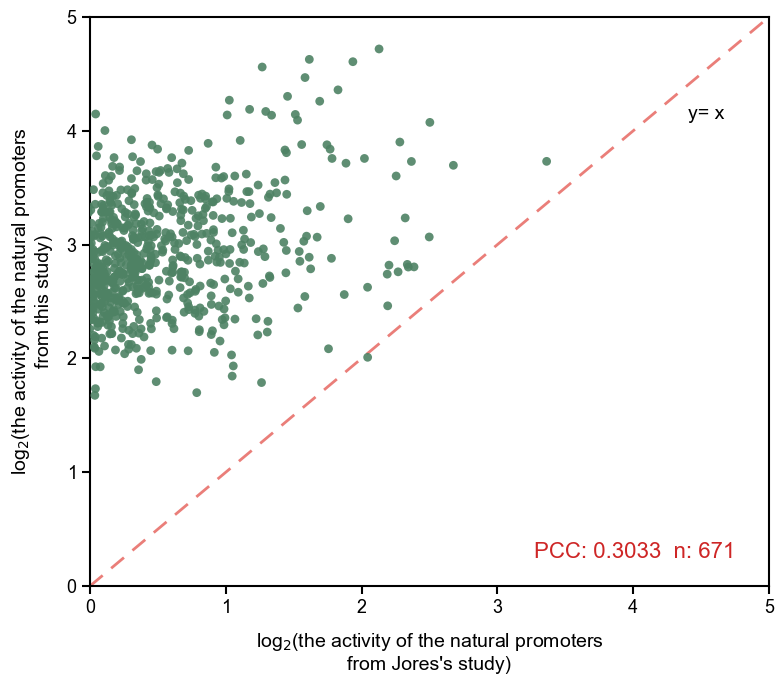

In [40]:
# Load Jores et al. data
# Reading from the relative path based on workspace structure
natural_df = pd.read_excel('../data/Natural_promoters.xlsx')

# 1. Re-extract NPs_df from the original last_df to ensure it is clean and does not contain previous merge results.
NPs_df = last_df[last_df.index.str.startswith('NP')].copy()

# 2. Merge to get enrichment values corresponding to NPs
# We perform an inner merge to find common sequences
plot_df = NPs_df.merge(natural_df[['sequence', 'enrichment']], on='sequence')

# Prepare X (Jores) and Y (This Study)
x_col = 'enrichment'
y_col = 'log2(activity_avg)'
clean_data = plot_df[[x_col, y_col]].dropna()
x = clean_data[x_col]
y = clean_data[y_col]

# Calculate PCC
pcc, _ = pearsonr(x, y)
n_count = len(clean_data)

# Setup Figure
fig, ax = plt.subplots(figsize=(8, 7))

# Scatter Plot
# Dark green color similar to the provided image
ax.scatter(x, y, color='#4E8264', s=40, alpha=0.9, edgecolors='none', zorder=5)

# Diagonal line y=x (dashed, pinkish-red)
ax.plot([0, 5], [0, 5], color='#EA7E79', linestyle='--', linewidth=2.0, dashes=(6, 4))
ax.text(4.4, 4.1, r'y= x', fontsize=14, color='black', fontweight='bold')

# Add Annotation Text (Red, Bottom Right)
stats_text = f'PCC: {pcc:.4f}  n: {n_count:,}'
ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, 
        fontsize=16, fontweight='bold', color='#CE2626', horizontalalignment='right')

# Labels and Title
ax.set_xlabel(r'log$_2$(the activity of the natural promoters' + '\n' + r"from Jores's study)", fontsize=14, labelpad=10)
ax.set_ylabel(r'log$_2$(the activity of the natural promoters' + '\n' + r'from this study)', fontsize=14, labelpad=10)

# Set Axis Limits
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Customize Spines (Thicker borders)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, direction='out')

plt.tight_layout()
# plt.savefig('./data_for_plot/figure4_jores_comparison.svg', dpi=600)
plt.show()

### 7.4 Distribution of SP Activity across Different Targets

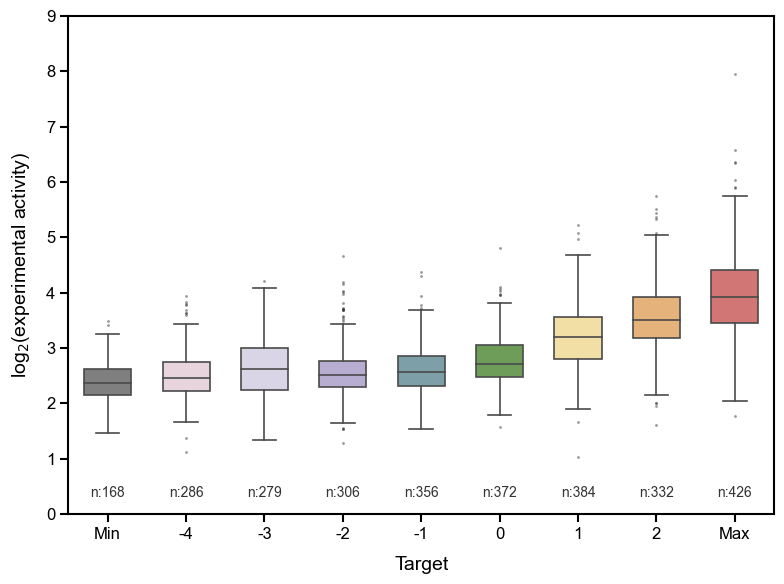

In [41]:
# 1. Prepare Data
# Re-extract SPs_df from the original last_df to ensure purity
SPs_df_clean = last_df[last_df.index.str.startswith('SP')].copy()

# Read TargetGAN data
target_seq = pd.read_excel('../data/targetgan_55296.xlsx')

# Merge data
plot_data = SPs_df_clean.merge(target_seq[['sequence', 'target']], on='sequence')
plot_data.rename(columns={'log2(activity_avg)': 'Experimental Activity'}, inplace=True)

# Define order
order = ['min', -4, -3, -2, -1, 0, 1, 2, 'max']

# Custom color palette matching Figure 3 style but specific for targets here
custom_palette = {
    'min': '#7F7F7F',   # Grey
    -4: '#EAD1DC',      # Light Pink/Beige
    -3: '#D9D2E9',      # Light Purple
    -2: '#B4A7D6',      # Purple
    -1: '#76A5AF',      # Teal
    0:  '#6AA84F',      # Green
    1:  '#FFE599',      # Yellow
    2:  '#F6B26B',      # Orange
    'max': '#E06666'    # Red
}

labels_map = {
    'min': 'Min', -4: '-4', -3: '-3', -2: '-2', -1: '-1', 0: '0', 1: '1', 2: '2', 'max': 'Max'
}

# 3. Plotting
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x='target', 
            y='Experimental Activity', 
            data=plot_data, 
            order=order,
            palette=custom_palette,
            width=0.6,
            linewidth=1.2,
            fliersize=2,
            flierprops=dict(marker='o', markerfacecolor='#333333', markeredgecolor='none', alpha=0.5))

# Add N-value annotations
counts = plot_data['target'].value_counts()

# Set Y-axis range from 0 to 9 to fit text
plt.ylim(0, 9)

for i, label in enumerate(order):
    n_val = counts.get(label, 0)
    # Add text below the boxplot
    # Position: slightly above 0 or at a fixed low Y
    ax.text(i, 0.3, f"n:{n_val:,}", horizontalalignment='center', fontsize=10, color='#333333')

# Set axis labels
plt.xlabel('Target', fontsize=14, labelpad=10) 
plt.ylabel(r'log$_2$(experimental activity)', fontsize=14, labelpad=10)

# Set tick labels to Min/Max (capitalized)
new_labels = [labels_map.get(l, str(l)) for l in order]
ax.set_xticklabels(new_labels, fontsize=12)

# Y-axis ticks
plt.yticks(range(10), fontsize=12)

# Adjust spines and ticks to match Figure 3 style
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', width=1.5, length=6, direction='out')

plt.tight_layout()
# Save figure
# plt.savefig('./data_for_plot/figure4_boxplot_targets.svg', dpi=600)
plt.show()

### 7.5 Comparison of Activity Ranges between SPs and NPs

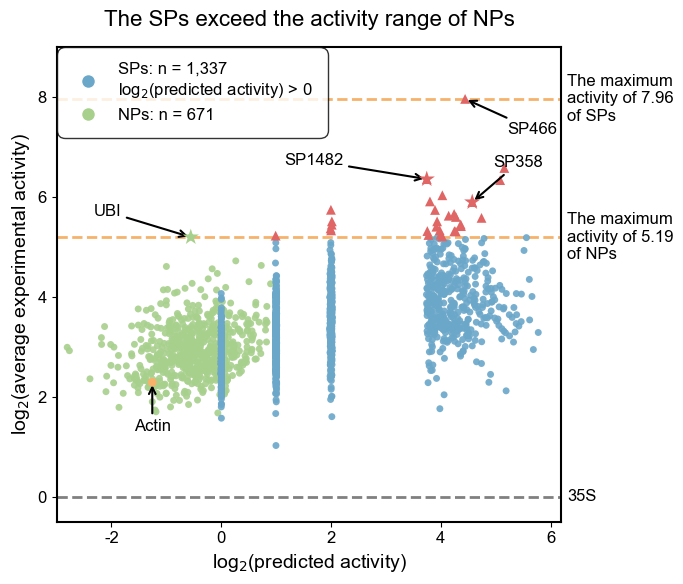

In [47]:
# Filter SPs based on image criteria (log2(predicted activity) > 0)
SPs_filtered = SPs_df[SPs_df['log2(predicted_activity)'] > 0].copy()
NPs_filtered = NPs_df.copy()

# Define thresholds
max_np_activity = 5.19
max_sp_activity = 7.96 # From image text

# Split SPs into "Normal" (<= Max NP) and "High" (> Max NP)
sps_low = SPs_filtered[SPs_filtered['log2(activity_avg)'] <= max_np_activity]
sps_high = SPs_filtered[SPs_filtered['log2(activity_avg)'] > max_np_activity]

# Specific points to highlight
highlight_sps = ['SP1482', 'SP358'] # Stars
highlight_sp_arrow = ['SP466'] # Pointed to
highlight_nps = ['UBI'] # Star
highlight_actin = ['Actin'] # Orange dot

# --- 2. Plotting ---
plt.figure(figsize=(7, 6))
ax = plt.gca()

# 2.1 Base Scatter Plots
# NPs (Green)
plt.scatter(
    NPs_filtered['log2(predicted_activity)'], 
    NPs_filtered['log2(activity_avg)'], 
    s=25, c='#A8D08D', alpha=0.9, edgecolors='none',
    label=f'NPs: n = {len(NPs_filtered):,}'
)

# SPs Low (Blue)
plt.scatter(
    sps_low['log2(predicted_activity)'], 
    sps_low['log2(activity_avg)'], 
    s=25, c='#6BA7C9', alpha=0.9, edgecolors='none',
    label=f'SPs: n = {len(SPs_filtered):,}\nlog$_2$(predicted activity) > 0'
)

# SPs High (Red Triangles)
plt.scatter(
    sps_high['log2(predicted_activity)'], 
    sps_high['log2(activity_avg)'], 
    s=50, c='#E06666', marker='^', alpha=1.0, edgecolors='none'
)

# 2.2 Reference Lines
# 35S Baseline (y=0)
plt.axhline(y=0, color='grey', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, 0, '35S', va='center', fontsize=12, color='black') # Moved x to 6.3

# Max NP Line (y=5.19)
plt.axhline(y=max_np_activity, color='#F6B26B', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, max_np_activity, f'The maximum\nactivity of {max_np_activity}\nof NPs', 
         va='center', fontsize=12, color='black', ha='left')

# Max SP Line (y=7.96)
plt.axhline(y=max_sp_activity, color='#F6B26B', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, max_sp_activity, f'The maximum\nactivity of {max_sp_activity}\nof SPs', 
         va='center', fontsize=12, color='black', ha='left')

# 2.3 Highlights
# UBI (Green Star) - Adjusted position to avoid overlap
ubi_data = NPs_filtered[NPs_filtered['gene'] == 'UBI']
if not ubi_data.empty:
    plt.scatter(ubi_data['log2(predicted_activity)'], ubi_data['log2(activity_avg)'], 
                s=150, c='#A8D08D', marker='*', edgecolors='none', zorder=10)
    plt.annotate('UBI', 
                 xy=(ubi_data['log2(predicted_activity)'].values[0], ubi_data['log2(activity_avg)'].values[0]),
                 xytext=(-50, 15), textcoords='offset points', # Shifted Left & Up
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, fontweight='normal', ha='right')

# Actin (Orange Dot) - Adjusted position
actin_data = NPs_filtered[NPs_filtered['gene'] == 'Actin']
if not actin_data.empty:
    plt.scatter(actin_data['log2(predicted_activity)'], actin_data['log2(activity_avg)'], 
                s=40, c='#F6B26B', marker='o', edgecolors='none', zorder=10)
    plt.annotate('Actin', 
                 xy=(actin_data['log2(predicted_activity)'].values[0], actin_data['log2(activity_avg)'].values[0]),
                 xytext=(0, -35), textcoords='offset points', # Shifted Down
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, fontweight='normal', ha='center')

# SPs Highlights (Red Stars for SP1482, SP358)
for sp_name in highlight_sps:
    if sp_name in SPs_filtered.index:
        sp_data = SPs_filtered.loc[[sp_name]]
    elif 'name1' in SPs_filtered.columns and sp_name in SPs_filtered['name1'].values:
        sp_data = SPs_filtered[SPs_filtered['name1'] == sp_name]
    else:
        continue
        
    plt.scatter(sp_data['log2(predicted_activity)'], sp_data['log2(activity_avg)'], 
                s=150, c='#E06666', marker='*', edgecolors='none', zorder=10)
    
    # Adjusted annotations for SP1482 and SP358 to avoid clutter
    if sp_name == 'SP1482':
        # SP1482: Move Left and slightly Up to clear the vertical band
        offset = (-60, 10) 
        ha = 'right'
    else: # SP358
        # SP358: Move Up and Right to clear cluster
        offset = (15, 25)
        ha = 'left'
    
    plt.annotate(sp_name, 
                 xy=(sp_data['log2(predicted_activity)'].values[0], sp_data['log2(activity_avg)'].values[0]),
                 xytext=offset, textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, ha=ha)

# SP466 (Arrow only to triangle)
if 'SP466' in SPs_filtered.index:
    sp_data = SPs_filtered.loc[['SP466']]
    plt.annotate('SP466', 
                 xy=(sp_data['log2(predicted_activity)'].values[0], sp_data['log2(activity_avg)'].values[0]),
                 xytext=(30, -25), textcoords='offset points', # Shifted Right & Down
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12)


# 2.4 Formatting
plt.xlabel(r'log$_2$(predicted activity)', fontsize=14)
plt.ylabel(r'log$_2$(average experimental activity)', fontsize=14)
plt.title('The SPs exceed the activity range of NPs', fontsize=16, fontweight='bold', pad=15)

# Axis limits and ticks
plt.xlim(-3, 6.2) 
plt.ylim(-0.5, 9)

# Spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'SPs: n = {len(SPs_filtered):,}\nlog$_2$(predicted activity) > 0',
           markerfacecolor='#6BA7C9', markersize=10),
    Line2D([0], [0], marker='o', color='w', label=f'NPs: n = {len(NPs_filtered):,}',
           markerfacecolor='#A8D08D', markersize=10)
]

leg = plt.legend(handles=legend_elements, loc='upper left', fontsize=12, 
           frameon=True, edgecolor='black', fancybox=True)
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_boxstyle("Round,pad=0.5")


plt.tight_layout()
plt.show()

### 8.1 LUC Result Data Processing and Saving
This section processes the LUC/REN ratio data, normalizes it to 35S, and exports the final results.

In [19]:
# 1. Load and preprocess data
def load_and_process(fluc_file, nluc_file):
    luc = pd.read_csv(fluc_file, sep='\t', header=None)
    nluc = pd.read_csv(nluc_file, sep='\t', header=None)
    nluc = nluc.mask(nluc < 10000, np.nan)
    return luc / nluc

result_1 = load_and_process('../data/fluc_1.txt', '../data/nluc_1.txt')
result_2 = load_and_process('../data/fluc_2.txt', '../data/nluc_2.txt')
last = (result_1 + result_2) / 2
plate = last.apply(pd.to_numeric, errors='coerce').to_numpy()

# 2. Load metadata and STARR-seq activity from luc_seq.xlsx
# The user indicated that luc_seq.xlsx contains 'name' and 'log2(STARR-seq activity)'
meta_df = pd.read_excel('../data/luc_seq.xlsx')
name_list = meta_df['name'].dropna().astype(str).tolist()

# 3. Build plate coordinates and long-format records
coords = [(row, col) for col in range(12) for row in range(4)] + \
         [(row, col) for col in range(9) for row in range(4, 8)]

records = []
for i, (row, col) in enumerate(coords):
    sample_id = i // 4 + 1
    sample_name = name_list[sample_id - 1] if sample_id - 1 < len(name_list) else f'sample_{sample_id}'
    records.append({
        'sample_id': sample_id,
        'sample_name': sample_name,
        'replicate': i % 4 + 1,
        'row': row,
        'col': col,
        'value': plate[row, col],
    })

long_df = pd.DataFrame(records)
wide_df = long_df.pivot(index='sample_name', columns='replicate', values='value')

# Rename columns to match the plate header style
wide_df.columns = [f'Repeat {col}' for col in wide_df.columns]

# =====================================================================
# Normalization: Normalize to '35S' mean and take log2
# =====================================================================
if '35S' in wide_df.index:
    # Get 35S mean across repeats
    ref_value = wide_df.loc['35S'].mean()
    
    # Divide by reference and take log2
    wide_df = np.log2(wide_df / ref_value)
    
    # Drop 35S from the final table if desired
    wide_df.drop(index=['35S'], errors='ignore', inplace=True)
else:
    print("Warning: '35S' not found in data. Skipping normalization.")
    ref_value = 1.0 # Default fallback

# =====================================================================

# 5. Calculate Average LUC activity
wide_df['Average activity'] = wide_df.mean(axis=1)

# 6. Sort rows: UBI first, then descending by Average activity
if 'UBI' in wide_df.index:
    ubi_row = wide_df.loc[['UBI']]
    rest_df = wide_df.drop(index='UBI').sort_values(by='Average activity', ascending=False)
    final_df = pd.concat([ubi_row, rest_df])
else:
    final_df = wide_df.sort_values(by='Average activity', ascending=False)

# 7. Merge with STARR-seq activity from meta_df if available
# Check if 'log2(STARR-seq activity)' is in meta_df
if 'log2(STARR-seq activity)' in meta_df.columns:
    # Create a mapping from name to STARR-seq activity
    starr_map = meta_df.set_index('name')['log2(STARR-seq activity)']
    # Add to final_df
    final_df['log2(STARR-seq activity)'] = final_df.index.map(starr_map)

# 8. Format output
final_df_display = final_df.apply(lambda col: col.map('{:.4f}'.format) if pd.api.types.is_numeric_dtype(col) else col)
final_df_display.index.name = None
final_df_display.to_excel('../data/luc_result.xlsx')

print(final_df_display)

       Repeat 1 Repeat 2 Repeat 3 Repeat 4 Average activity  \
UBI      6.1894   6.2209   5.9875   6.4106           6.2021   
SP1482   6.9695   6.8989   7.0576   7.3612           7.0718   
SP358    5.9839   6.9148   6.4287      nan           6.4424   
SP680    4.9794   5.5906   4.2636   5.2284           5.0155   
SP1790   5.3422   4.2831   4.8124   4.0574           4.6237   
SP954    4.6564   4.9091   4.1623   4.6330           4.5902   
SP123       nan   4.3978   4.2314   4.5049           4.3780   
SP92     3.3924   4.8760   3.4315   4.7946           4.1236   
SP1361   2.3898   3.0399   2.2151   2.7111           2.5890   
SP1526      nan   1.3167   2.1543   2.1472           1.8727   
SP2657   1.8569   1.0544   1.7138   1.2755           1.4752   
SP3251   0.6034   1.5725   1.3202   0.6698           1.0415   
SP466    0.6742   0.8083   0.9615   1.1523           0.8991   
SP4193  -0.9922   1.3982  -0.8172  -0.8459          -0.3143   
SP5066   0.4515  -1.9736  -0.9546      nan          -0.

### 8.2 Correlation between STARR-seq and LUC Activity
This section merges STARR-seq activity metrics with LUC assay results to evaluate their correlation.

Data ready. N=19
        log2(experimental activity, average)  log2_final
UBI                                 5.194439    6.202105
SP1482                              6.354865    7.071805
SP358                               5.895654    6.442434
SP680                               5.657723    5.015491
SP1790                              3.614888    4.623741


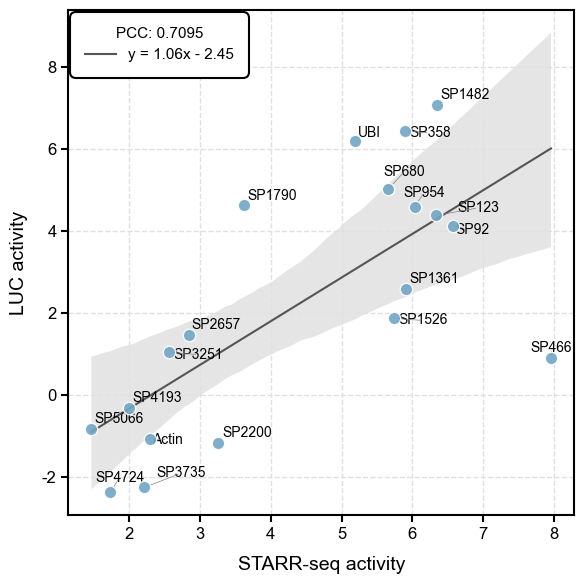

In [22]:
# ---------------------------------------------------------
# 1. Prepare Data for Correlation Analysis
# ---------------------------------------------------------
# Since we now have 'log2(STARR-seq activity)' directly in final_df (from luc_seq.xlsx),
# we can use final_df directly instead of merging with last_df.

# Ensure final_df is clean
final_df.dropna(subset=['Average activity'], inplace=True)

# Check if we have the STARR-seq column
if 'log2(STARR-seq activity)' in final_df.columns:
    compare_df = final_df.copy()
    compare_df.rename(columns={
        'log2(STARR-seq activity)': 'log2(experimental activity, average)',
        'Average activity': 'log2_final'
    }, inplace=True)
    # Filter out rows where STARR-seq activity might be missing
    compare_df.dropna(subset=['log2(experimental activity, average)', 'log2_final'], inplace=True)
else:
    # Fallback to merging with last_df if the column is missing for some reason
    print("STARR-seq column not found in final_df. Attempting merge with last_df...")
    if 'last_df' in locals():
        compare_df = pd.merge(last_df[['log2(activity_avg)']], 
                              final_df[['Average activity']], 
                              left_index=True, 
                              right_index=True, 
                              how='inner')
        compare_df.rename(columns={
            'log2(activity_avg)': 'log2(experimental activity, average)',
            'Average activity': 'log2_final'
        }, inplace=True)
    else:
        raise ValueError("Cannot find STARR-seq data. Please ensure 'log2(STARR-seq activity)' is in luc_seq.xlsx or last_df is defined.")

print(f"Data ready. N={len(compare_df)}")
print(compare_df[['log2(experimental activity, average)', 'log2_final']].head())

# ---------------------------------------------------------
# 2. Plot Correlation
# ---------------------------------------------------------
x = compare_df['log2(experimental activity, average)']
y = compare_df['log2_final']

# Use square figure
fig, ax = plt.subplots(figsize=(6, 6))

# Regression line
sns.regplot(x=x, y=y, ax=ax, scatter=False, color='#555555', 
            line_kws={'linewidth': 1.5}, ci=95)

# Scatter points
lines = [line for line in ax.lines]
points = ax.scatter(x, y, s=80, color='#72a5c5', alpha=0.9, edgecolors='white', linewidths=1.0, zorder=5)

# Pearson correlation
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
sign = '+' if intercept >= 0 else '-'
eq_label = f'y = {slope:.2f}x {sign} {abs(intercept):.2f}'

# Annotate points with adjustText
from adjustText import adjust_text
texts = []
for i, txt in enumerate(compare_df.index):
    texts.append(ax.text(x.iloc[i], y.iloc[i], txt, fontsize=10, fontweight='bold'))

# Legend
line_legend = mlines.Line2D([], [], color='#555555', linewidth=1.5, label=eq_label)
leg = ax.legend(handles=[line_legend], title=f'PCC: {r_value:.4f}', loc='upper left', 
                frameon=True, fontsize=11, title_fontsize=11, 
                edgecolor='black', facecolor='white', framealpha=1, borderpad=0.6)
leg.get_frame().set_linewidth(1.5)
leg.get_frame().set_boxstyle("Round,pad=0.4")

# Adjust text positions to avoid overlap
if texts:
    adjust_text(texts, 
                x=x.values, 
                y=y.values,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                add_objects=lines + [leg],
                expand_points=(1.2, 1.2)
            )

# Labels and Ticks
ax.set_xlabel('STARR-seq activity', fontsize=14, labelpad=10)
ax.set_ylabel('LUC activity', fontsize=14, labelpad=10)

ax.grid(True, linestyle='--', linewidth=1.0, color='#e0e0e0', zorder=0)

# Spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', labelsize=12, length=5, width=1.5, direction='out')

plt.tight_layout()
plt.savefig('./data_for_plot/luc_correlation.svg', dpi=1000)
plt.show()

### 8.3 Bar Plot Comparison for Selected Promoters
This panel compares the activity of selected promoters (UBI, SP1482, and SP358) between STARR-seq and LUC assays.

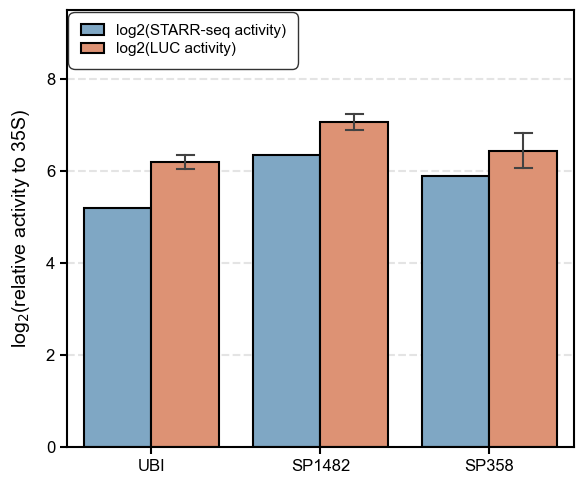

In [28]:
# --- 8. Bar Plot for Selected Promoters (UBI, SP1482, SP358) ---
selected_genes = ['UBI', 'SP1482', 'SP358']

# 1. Prepare Data
# Use final_df directly as it contains both LUC repeats and STARR-seq activity.
if 'final_df' not in locals():
    # Attempt to reload if not present (assuming 8.1 was run and saved)
    try:
        final_df = pd.read_excel('../data/luc_result.xlsx', index_col=0)
    except:
        print("Error: final_df not found. Please run Section 8.1 first.")

df_plot = final_df.loc[selected_genes].copy()

# 2. Reshape for Seaborn
plot_records = []

for gene in selected_genes:
    # Extract STARR-seq value (Single value)
    starr_val = df_plot.loc[gene, 'log2(STARR-seq activity)']
    plot_records.append({
        'Gene': gene,
        'Type': 'log2(STARR-seq activity)',
        'Activity': starr_val
    })
    
    # Extract LUC Repeats (Multiple values)
    luc_cols = [c for c in df_plot.columns if 'Repeat' in c]
    for col in luc_cols:
        val = df_plot.loc[gene, col]
        if pd.notna(val):
            plot_records.append({
                'Gene': gene,
                'Type': 'log2(LUC activity)',
                'Activity': val
            })

bar_data = pd.DataFrame(plot_records)

# 3. Plotting
fig, ax = plt.subplots(figsize=(6, 5))

# Colors from previous attempts (Blue/Orange)
palette = {'log2(STARR-seq activity)': '#74a9cf', 'log2(LUC activity)': '#ef8a62'}
hue_order = ['log2(STARR-seq activity)', 'log2(LUC activity)']

# Draw Bar Plot
# ci='sd' draws the standard deviation as error bars automatically for groups with multiple values (LUC)
# Groups with single value (STARR-seq) will have no error bars.
sns.barplot(
    x='Gene', y='Activity', hue='Type', data=bar_data, 
    ax=ax, palette=palette, edgecolor='black', linewidth=1.5,
    order=selected_genes, hue_order=hue_order,
    ci='sd', capsize=0.1, errwidth=1.5, zorder=2
)

# 4. Formatting to match reference image
ax.set_ylabel(r'log$_2$(relative activity to 35S)', fontsize=14, labelpad=10)
ax.set_xlabel('', fontsize=14)
ax.set_xticklabels(selected_genes, fontsize=12, fontweight='bold', color='black')
# Axis limits usually 0-9 based on previous context, image shows ~9 top check
ax.set_ylim(0, 9.5)

# Grid lines (Horizontal, dashed, gray)
ax.yaxis.grid(True, linestyle='--', linewidth=1.5, color='#d9d9d9', alpha=0.7, zorder=0)
ax.set_axisbelow(True)

# Spines (Black box)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Ticks
ax.tick_params(axis='both', which='major', width=1.5, length=5, direction='out', labelsize=12, colors='black')

# Legend (Top Left, White Box with Black Edge)
leg = ax.legend(loc='upper left', frameon=True, fontsize=11, 
                handlelength=1.5, borderpad=0.4, labelspacing=0.3)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_boxstyle("Round,pad=0.4")

plt.tight_layout()
plt.savefig('./data_for_plot/luc_bar_comparison.svg', dpi=1000)
plt.show()